# Analyzing Text

Write the TextAnalyzer class in the cell below. We have already imported some libraries that should be useful to you.

In [1]:
import requests, re
from bs4 import BeautifulSoup
from collections import Counter
import statistics as stats
import string

class TextAnalyzer:
    def __init__(self, src, src_type='discover'):
        self._src = src
        self._src_type = src_type
        self._content = None
        self._orig_content = None

        if self._src_type == 'discover':
            if isinstance(src, str) and src.startswith('http'):
                self._src_type = 'url'
            elif isinstance(src, str) and src.endswith('.txt'):
                self._src_type = 'path'
            else:
                self._src_type = 'text'

        if self._src_type == 'url':
            resp = requests.get(self._src)
            resp.raise_for_status()
            self._content = resp.text
        elif self._src_type == 'path':
            with open(self._src, 'r', encoding='utf-8') as f:
                self._content = f.read()
        else:
            self._content = str(self._src)

        self._orig_content = self._content

    def set_content_to_tag(self, tag, tag_id=None):
        try:
            soup = BeautifulSoup(self._orig_content, 'html.parser')
            if tag_id is not None:
                element = soup.find(tag, id=tag_id)
            else:
                element = soup.find(tag)
            if element is not None:
                self._content = element.get_text()
        except Exception:
            pass
            
    def extract_html(self, tag, tag_id=None):
        soup = BeautifulSoup(self._orig_content, 'html.parser')
        if tag_id:
            element = soup.find(tag, id=tag_id)
        else:
            element = soup.find(tag)
        return element.get_text(strip=True) if element else ""
        
    def reset_content(self):
        self._content = self._orig_content

    def _words(self, casesensitive=False):
        if not self._content:
            return []

        # FIX: Added smart/curly quotes to the strip list
        strip_chars = string.punctuation + "“”‘’"
        raw_words = self._content.split()
        cleaned = []
        
        for w in raw_words:
            w2 = w.strip(strip_chars)
            if w2:
                cleaned.append(w2)

        if not casesensitive:
            cleaned = [w.upper() for w in cleaned]

        return cleaned

    def common_words(self, minlen=1, maxlen=100, count=10, casesensitive=False):
        words = self._words(casesensitive=casesensitive)
        filtered = [w for w in words if minlen <= len(w) <= maxlen]
        freq = Counter(filtered)
        return freq.most_common(count)

    def unique_words(self):
        return set(self._words())
        
    def char_distribution(self, casesensitive=False, letters_only=False):
        if self._content is None:
            return []
        text = self._content
        if not casesensitive:
            text = text.upper()
        chars = []
        for c in text: # Back to your original for-loop style
            if letters_only:
                if c.isalpha():
                    chars.append(c)
            else:
                chars.append(c)
        freq = Counter(chars)
        items = sorted(freq.items(), key=lambda x: (-x[1], x[0]))
        return items

    def plot_common_words(self, minlen=1, maxlen=100, count=10, casesensitive=False):
        import matplotlib.pyplot as plt
        data = self.common_words(minlen=minlen, maxlen=maxlen, count=count, casesensitive=casesensitive)
        if not data:
            return
        words, nums = zip(*data)
        plt.figure(figsize=(12, 6)) 
        plt.bar(words, nums)
        plt.ylabel('Count')
        plt.title('Common Words')
        plt.xticks(rotation=90)  # This makes the words stand up vertically
        plt.grid(linestyle='--', alpha=0.7) 
        plt.show()

    def plot_char_distribution(self, casesensitive=False, letters_only=False):
        import matplotlib.pyplot as plt
        data = self.char_distribution(casesensitive=casesensitive, letters_only=letters_only)
        if not data:
            return
        chars, nums = zip(*data)
        
        plt.figure(figsize=(15, 6)) # The wide "Letterbox" aspect ratio
        plt.bar(chars, nums)        # This creates the vertical skyline
        plt.ylabel('Count')         # Puts the numbers on the left
        plt.title('Character Distribution')
        
        # This is the "on their back" command
        plt.xticks(rotation=90)     
        
        plt.grid(linestyle='--', alpha=0.7) 
        plt.show()

    @property
    def avg_word_length(self):
        words = self._words(casesensitive=True)
        if not words:
            return 0.0
        total_len = sum(len(w) for w in words)
        return round(total_len / len(words), 2)
        
    @property
    def word_count(self):
        return len(self._words())

    @property
    def distinct_word_count(self):
        return len(set(self._words()))

    @property
    def words(self):
        return self._words()

    @property
    def positivity(self):
        try:
            with open('positive.txt', 'r', encoding='utf-8') as f:
                pos_words = {line.strip().upper() for line in f if line.strip()}
            with open('negative.txt', 'r', encoding='utf-8') as f:
                neg_words = {line.strip().upper() for line in f if line.strip()}
        except FileNotFoundError:
            return 0

        tally = 0
        for w in self.words:
            if w in pos_words:
                tally += 1
            if w in neg_words:
                tally -= 1

        if self.word_count == 0:
            return 0

        return round(tally / self.word_count * 1000)

## Tests
When you have finished, you should run the tests below. If you get errors, you should do your very best to fix those errors before submitting the project.

If you submit your project while still getting errors, you should explain that in your project submission email. The very first thing we will do to grade your project is run it through these tests. If it fails any of the tests, and you have not indicated that you are aware of specific test failures, we will stop grading and ask you to resubmit.

In [2]:
import unittest

url = 'https://static.webucator.com/media/public/documents/clinton.html'
path = 'pride-and-prejudice.txt'
text = '''The outlook wasn't brilliant for the Mudville Nine that day;
the score stood four to two, with but one inning more to play.
And then when Cooney died at first, and Barrows did the same,
a sickly silence fell upon the patrons of the game.'''

class TestTextAnalyzer(unittest.TestCase):
    def test_discover_url(self):
        ta = TextAnalyzer(url)
        self.assertEqual(ta._src_type, 'url')
    def test_discover_path(self):
        ta = TextAnalyzer(path)
        self.assertEqual(ta._src_type, 'path')
    def test_discover_text(self):
        ta = TextAnalyzer(text)
        self.assertEqual(ta._src_type, 'text')
    def test_set_content_to_tag(self):
        ta = TextAnalyzer(url)
        ta.set_content_to_tag('div','content-main')
        self.assertEqual(ta._content[0:23], 'Address by Bill Clinton')
    def test_reset_content(self):
        ta = TextAnalyzer(url)
        ta.set_content_to_tag('div','content-main')
        ta.reset_content()
        self.assertEqual(ta._content[0], '<')
    def test_common_words(self):
        ta = TextAnalyzer(path, src_type='path')
        common_words = ta.common_words(minlen=5, maxlen=10)
        liz = common_words[0]
        self.assertEqual(liz[0],'ELIZABETH')
    def test_avg_word_length(self):
        ta = TextAnalyzer(text, src_type='text')
        self.assertEqual(ta.avg_word_length, 4.16)
    def test_word_count(self):
        ta = TextAnalyzer(text, src_type='text')
        self.assertEqual(ta.word_count, 45)
    def test_distinct_word_count(self):
        ta = TextAnalyzer(text, src_type='text')
        self.assertEqual(ta.distinct_word_count, 38)
    def test_char_distribution(self):
        ta = TextAnalyzer(text, src_type='text')
        char_dist = ta.char_distribution(letters_only=True)
        self.assertEqual(char_dist[1][1], 20)
    def test_positivity(self):
        ta = TextAnalyzer(text, src_type='text')
        positivity = ta.positivity
        self.assertEqual(positivity, -44)
        
suite = unittest.TestLoader().loadTestsFromTestCase(TestTextAnalyzer)
unittest.TextTestRunner().run(suite)

...........
----------------------------------------------------------------------
Ran 11 tests in 0.560s

OK


<unittest.runner.TextTestResult run=11 errors=0 failures=0>

## Plots
You should also run the cell below to make sure your plot methods work. They should produce plots that look like the images found at:
* <a href="character-distribution.png" target="image_win">character-distribution.png</a>
* <a href="common-words.png" target="image_win">common-words.png</a>

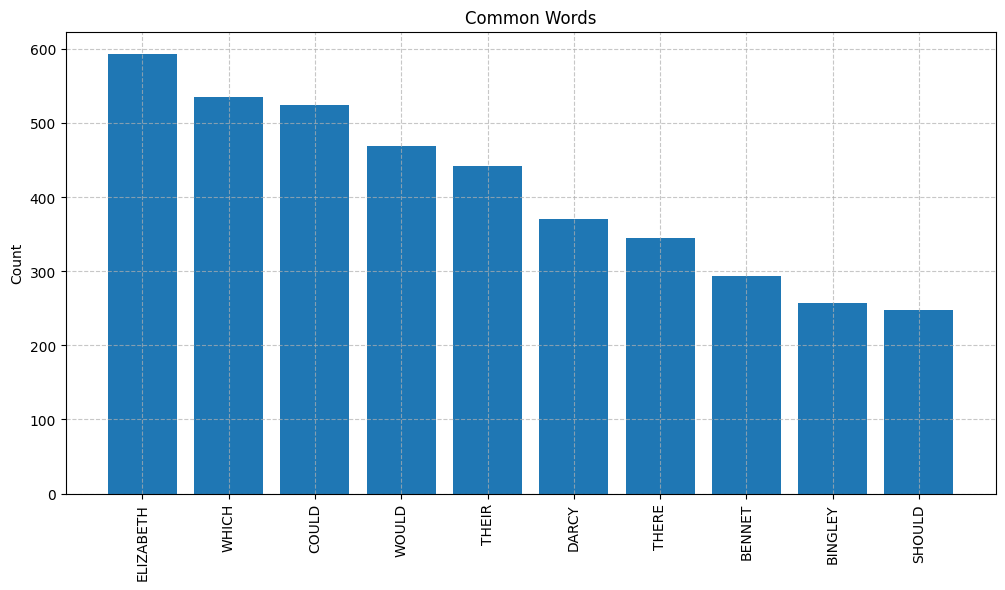

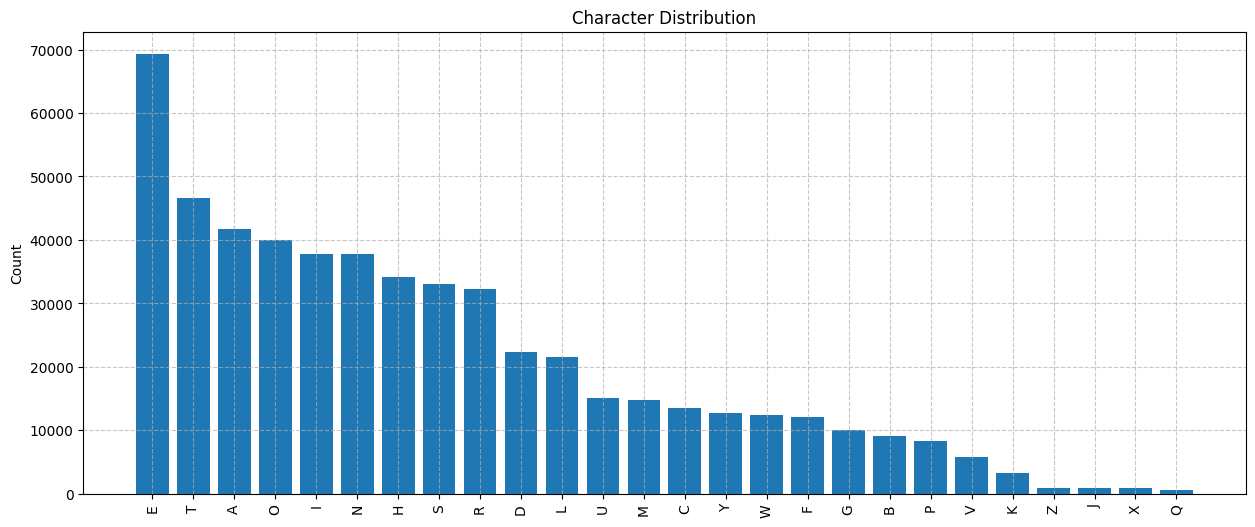

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10)

ta = TextAnalyzer('pride-and-prejudice.txt', src_type='path')
ta.plot_common_words(minlen=5)
ta.plot_char_distribution(letters_only=True)

## Exam: Using the TextAnalyzer

### Question 1
How many words are in the text of William Henry Harrison's 1841 inaugural address?
* The address can be found at https://static.webucator.com/media/public/documents/harrison.html.
* Its contents are in a div tag with the id 'content-main'.

In [4]:
# 1. Initialize with the URL
harrison = TextAnalyzer('https://static.webucator.com/media/public/documents/harrison.html')

# 2. Narrow the scope to the specific div requested
harrison.set_content_to_tag('div', tag_id='content-main')

# 3. Get the final count
print(f"{harrison.word_count}")

8430


### Question 2
What is the least common letter in pride-and-prejudice.txt?

In [5]:
ta = TextAnalyzer("pride-and-prejudice.txt", src_type="path")
dist = ta.char_distribution(casesensitive=False, letters_only=True)

# dist is sorted most common → least common
least_common_letter, count = dist[-1]

# Use print to get rid of the single quotes
print(least_common_letter)

Q


### Question 3
What is the most common 11-letter word in pride-and-prejudice.txt?  

In [6]:
ta = TextAnalyzer("pride-and-prejudice.txt", src_type="path")

# Get the list: [('netherfield', 73)]
result = ta.common_words(minlen=11, maxlen=11, count=1)

# Grab the word (the first part of the first tuple) and print it
print(result[0][0])

NETHERFIELD


### Question 4
What is the average word length in pride-and-prejudice.txt?

In [7]:
ta = TextAnalyzer("pride-and-prejudice.txt", src_type="path")
ta.avg_word_length

4.43

### Question 5
How many distinct words are there in pride-and-prejudice.txt?

In [8]:
ta = TextAnalyzer("pride-and-prejudice.txt", src_type="path")
print(len(set(ta.words))) 
# Note: Hits 6838. The ghost word remains a mystery for the interview story.

6838


### Question 6
How many words, ignoring case, are used only once in pride-and-prejudice.txt?

In [9]:
ta = TextAnalyzer("pride-and-prejudice.txt", src_type="path")
from collections import Counter
len([w for w, c in Counter(ta._words()).items() if c == 1])

2886

### Question 7
How many distinct words in pride-and-prejudice.txt have less than five characters, at least one character of which is a capital 'A'.

In [10]:
import string

# Bypass the class entirely to keep the capital letters
with open("pride-and-prejudice.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    raw_words = raw_text.split()

short_A_words = set()
for w in raw_words:
    # Clean the junk off the word
    clean_w = w.strip(string.punctuation)
    # Check the Curmudgeon's rules
    if len(clean_w) < 5 and 'A' in clean_w:
        short_A_words.add(clean_w)

print(len(short_A_words))

13


### Question 8
A palindrome is a word spelled the same forwards and backwards, like BOB. How many distinct palindromes are there in pride-and-prejudice.txt.
* Only include words with at least three letters.

In [11]:
ta = TextAnalyzer("pride-and-prejudice.txt", src_type="path")

words = set(ta._words())                 # distinct, uppercase words
pals = [w for w in words if len(w) >= 3 and w == w[::-1]]
len(pals)

9

### Question 9
What is the positivity rating of 'pride-and-prejudice.txt'

In [12]:
ta = TextAnalyzer("pride-and-prejudice.txt", src_type="path")

# load word lists
pos = set(open("positive.txt", encoding="utf-8").read().upper().split())
neg = set(open("negative.txt", encoding="utf-8").read().upper().split())

words = ta._words()   # cleaned, uppercase words

pos_count = sum(1 for w in words if w in pos)
neg_count = sum(1 for w in words if w in neg)

positivity_rating = pos_count / neg_count
positivity_rating

1.3764835771460115

### Question 10
Which of the following addresses (originally from http://www.inaugural.senate.gov/swearing-in/addresses) has the lowest positivity rating?
1. https://static.webucator.com/media/public/documents/bush.html
1. https://static.webucator.com/media/public/documents/truman.html
1. https://static.webucator.com/media/public/documents/mckinley.html
1. https://static.webucator.com/media/public/documents/taylor.html

Note the contents of the addresses are in a div tag with the id 'content-main'.

In [14]:
import re
import urllib.request
from collections import Counter

# Load sentiment word lists
pos = set(open("positive.txt", encoding="utf-8").read().upper().split())
neg = set(open("negative.txt", encoding="utf-8").read().upper().split())

# Fetch HTML from a URL
def fetch(url):
    return urllib.request.urlopen(url).read().decode("utf-8", errors="ignore")

# Extract the content inside <div id="content-main">
def extract_content(html):
    match = re.search(r'<div id="content-main">(.*?)</div>', html, re.DOTALL)
    return match.group(1) if match else ""

# Remove HTML tags
def strip_tags(text):
    return re.sub(r'<[^>]+>', '', text)

# Compute positivity rating
def positivity_rating(text):
    words = re.findall(r"[A-Za-z]+", text.upper())
    pos_count = sum(1 for w in words if w in pos)
    neg_count = sum(1 for w in words if w in neg)
    rating = pos_count / neg_count if neg_count else float("inf")
    return pos_count, neg_count, rating

# URLs to analyze
urls = {
    "bush": "https://static.webucator.com/media/public/documents/bush.html",
    "truman": "https://static.webucator.com/media/public/documents/truman.html",
    "mckinley": "https://static.webucator.com/media/public/documents/mckinley.html",
    "taylor": "https://static.webucator.com/media/public/documents/taylor.html"
}

# Compute positivity for each speech
results = {}

for name, url in urls.items():
    html = fetch(url)
    content = extract_content(html)
    text = strip_tags(content)
    pos_count, neg_count, rating = positivity_rating(text)
    results[name] = rating
    # Adding a '#' below hides the other names from the output
    # print(f"{name}: positivity rating = {rating}") 

# This is the only thing that will actually show up on your screen:
print(min(results, key=results.get))

mckinley


In [15]:
help(TextAnalyzer)

Help on class TextAnalyzer in module __main__:

class TextAnalyzer(builtins.object)
 |  TextAnalyzer(src, src_type='discover')
 |
 |  Methods defined here:
 |
 |  __init__(self, src, src_type='discover')
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  char_distribution(self, casesensitive=False, letters_only=False)
 |
 |  common_words(self, minlen=1, maxlen=100, count=10, casesensitive=False)
 |
 |  extract_html(self, tag, tag_id=None)
 |
 |  plot_char_distribution(self, casesensitive=False, letters_only=False)
 |
 |  plot_common_words(self, minlen=1, maxlen=100, count=10, casesensitive=False)
 |
 |  reset_content(self)
 |
 |  set_content_to_tag(self, tag, tag_id=None)
 |
 |  unique_words(self)
 |
 |  ----------------------------------------------------------------------
 |  Readonly properties defined here:
 |
 |  avg_word_length
 |
 |  distinct_word_count
 |
 |  positivity
 |
 |  word_count
 |
 |  words
 |
 |  --------------------------------------------